## Understanding New Pedap basal format
The basal format changed with the release of `PEDAP Public Dataset - Release 4 - 2025-04-10`
This notebook analyzes the differences.

In [1]:
import os, sys, time, random
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from matplotlib import pyplot as plt

filepath = os.getcwd()
print(filepath)
sys.path.append(os.path.join(filepath, '..','..'))

from src.find_periods import find_periods
from src import pandas_helper as ph
from src import date_helper,cdf,drawing

/Users/jan/git/nudgebg/babelbetes/notebooks/understand-pedap-dataset


## Load the data

The file name changed.

|Release| File Name                          | Size   |
|-|------------------------------------|--------|
|PEDAP Public Dataset - Release 3 - 2024-09-25.zip| PEDAPTandemBASALRATECHG.txt        | 41 MB  |
|PEDAP Public Dataset - Release 4 - 2025-04-10.zip|PEDAPTandemBASALDELIVERY.txt       | 257 MB |

Let's inspect

In [27]:
old_release = 'PEDAP Public Dataset - Release 3 - 2024-09-25.zip'
new_release = 'PEDAP Public Dataset - Release 4 - 2025-04-10.zip'
study_path_old = os.path.join(filepath, '..','..', 'data','raw',old_release)
study_path_new = os.path.join(filepath, '..','..', 'data','raw',new_release)
df_basal_old = ph.get_df(os.path.join(study_path_old, 'Data Files', 'PEDAPTandemBASALRATECHG.txt'))
df_basal_new = ph.get_df(os.path.join(study_path_new, 'Data Files', 'PEDAPTandemBASALDELIVERY.txt'))

df_cgm = ph.get_df(os.path.join(study_path_new, 'Data Files', 'PEDAPTandemCGMDATAGXB.txt'),  usecols=['RecID', 'PtID', 'DeviceDtTm', 'CGMValue','HighLowIndicator'])
df_patient = ph.get_df(os.path.join(study_path_new, 'Data Files', 'PtRoster.txt'))

In [28]:
display(old_release)
display(df_basal_old.head())

display(new_release)
display(df_basal_new.head())

'PEDAP Public Dataset - Release 3 - 2024-09-25.zip'

,PtID,RecID,DeviceDtTm,BasalRate
0,27,3,12/28/2020 1:26:18 PM,0.300
1,27,4,12/28/2020 2:21:15 PM,0.000
2,27,5,12/28/2020 2:26:14 PM,0.300
3,27,6,12/28/2020 2:36:14 PM,0.151
4,27,7,12/28/2020 2:41:32 PM,0.148


'PEDAP Public Dataset - Release 4 - 2025-04-10.zip'

,RecID,PtID,DeviceDtTm,BasalRate
0,264605,93,11/23/2020 12:03:01 AM,0.0
1,264606,93,11/23/2020 12:08:01 AM,0.0
2,264607,93,11/23/2020 12:13:01 AM,0.0
3,264608,93,11/23/2020 12:18:01 AM,0.0
4,264609,93,11/23/2020 12:23:01 AM,0.0


In [29]:
print(f"unique CGM patient ids in old release: {len(df_basal_old.PtID.unique())}")
print(f"unique CGM patient ids in new release: {len(df_basal_new.PtID.unique())}")

unique CGM patient ids in old release: 65
unique CGM patient ids in new release: 99


In [30]:
print(f"Length of basal data in old release: {len(df_basal_old)}")
print(f"Length of basal data in new release: {len(df_basal_new)}")

Length of basal data in old release: 898874
Length of basal data in new release: 7202625


We see we also have more patients. In the previous dataset we only saw 65 and assumed that this was because of the control group which didn't wear tandem devices. This was obviously wrong. The new dataset seems to have data from the SC group as well!

## Handle Duplicates

Drop obvious duplicates (in record id)

In [22]:
#print number of duplicates 
print(f"number of duplicates in old release: {df_basal_old.duplicated(subset=['PtID','DeviceDtTm','BasalRate']).sum()}")
print(f"number of duplicates in new release: {df_basal_new.duplicated(subset=['PtID','DeviceDtTm','BasalRate']).sum()}")

#remove duplicates
df_basal_old = df_basal_old.drop_duplicates(subset=['PtID','DeviceDtTm','BasalRate'])
df_basal_new = df_basal_new.drop_duplicates(subset=['PtID','DeviceDtTm','BasalRate'])

number of duplicates in old release: 75139
number of duplicates in new release: 367710


In [23]:
#temporal duplicates
print(f"There are {df_basal_new.duplicated(subset=['PtID','DeviceDtTm']).sum()} temporal duplicates in the new release.")
print("Example of temporal duplicates:")
display(df_basal_new.loc[df_basal_new.duplicated(subset=['PtID','DeviceDtTm'], keep=False)].sort_values(by=['PtID','DeviceDtTm']).head(10))

There are 68 temporal duplicates in the new release.
Example of temporal duplicates:


,RecID,PtID,DeviceDtTm,BasalRate
4013713,4358099,5,7/6/2021 2:25:26 PM,0.000
4013714,4358100,5,7/6/2021 2:25:26 PM,0.513
1801817,2109464,9,1/17/2021 8:59:38 PM,1.031
5566638,5923400,9,1/17/2021 8:59:38 PM,0.000
1801818,2109465,9,1/17/2021 9:04:38 PM,1.007
5566639,5923401,9,1/17/2021 9:04:38 PM,0.000
1801819,2109466,9,1/17/2021 9:09:38 PM,0.989
5566640,5923402,9,1/17/2021 9:09:38 PM,0.000
1802828,2110547,9,1/18/2021 6:49:39 AM,0.325
5648696,6005460,9,1/18/2021 6:49:39 AM,0.000


Text(0.5, 1.0, 'Basal Rate duplicates Min/Max')

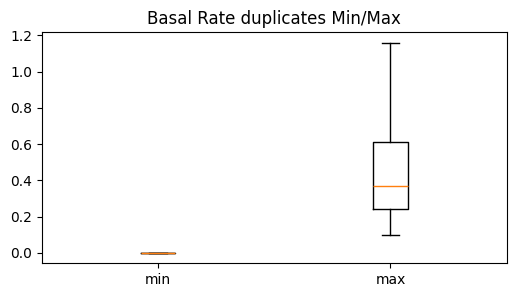

In [24]:
#compare duplicates min max values
minmax_dups = ph.get_min_max_duplicates(df_basal_new,['PtID','DeviceDtTm'],'BasalRate')
plt.figure(figsize=(6,3))
plt.boxplot([minmax_dups['min'].values,minmax_dups['max'].values],positions=[0,1],showfliers=False)
plt.xticks([0,1],['min','max'])
plt.title('Basal Rate duplicates Min/Max')

All values are either 0 or larger. We probably have to trust the non zero values. Since we are only dealing with 68 of them, this assumptions seems fair. Further investigation seems unnecessary.

In [31]:
_,_,i_drop = ph.get_duplicated_max_indexes(df_basal_new, ['PtID','DeviceDtTm'], 'BasalRate')
df_basal_new = df_basal_new.drop(index=i_drop)
print(f"After dropping duplicates, there are {df_basal_new.duplicated(subset=['PtID','DeviceDtTm']).sum()} duplicated rows (only considering PtID and DeviceDtTm) in the basal dataset")

After dropping duplicates, there are 0 duplicated rows (only considering PtID and DeviceDtTm) in the basal dataset


## Parsing DateTimes
As before we have dates with missing time component. Again, we assume these are midnight.

In [10]:
df_cgm['datetime'] = date_helper.parse_flair_dates(df_cgm['DeviceDtTm'])
df_basal_new['datetime'] = date_helper.parse_flair_dates(df_basal_new['DeviceDtTm'])
df_basal_old['datetime'] = date_helper.parse_flair_dates(df_basal_old['DeviceDtTm'])

In [11]:
df_cgm['date'] = df_cgm['datetime'].dt.date
df_basal_new['date'] = df_basal_new['datetime'].dt.date
df_basal_old['date'] = df_basal_old['datetime'].dt.date

## How much more data?

In [12]:
print(f"The old dataset has {df_basal_old.groupby(['PtID']).date.nunique().mean():.1f} unique dates per patient")
print(f"The new dataset has {df_basal_new.groupby(['PtID']).date.nunique().mean():.1f} unique dates per patient")

The old dataset has 89.0 unique dates per patient
The new dataset has 240.5 unique dates per patient


### CLC vs SC groups
Previously we assumed that all SC patients must be dropped. 
This is wrong. SC patients can use the Tandem control iq device after the first 13 weeks of data.

In [13]:
treatment_groups = df_patient.groupby('TrtGroup')

#merge treatment group to df_basal_new
df_basal_new = pd.merge(df_basal_new, df_patient[['PtID','TrtGroup']], on='PtID', how='inner')
df_basal_old = pd.merge(df_basal_old, df_patient[['PtID','TrtGroup']], on='PtID', how='inner')


In [14]:
#print the number of patients with basal data in each treatment group
clc_ids = treatment_groups.get_group('CLC').PtID.unique()
sc_ids = treatment_groups.get_group('SC').PtID.unique()

print(f"Of all {len(clc_ids)} CLC patient IDs, {len(np.intersect1d(df_basal_new.PtID.unique(),clc_ids))} have basal data in the new release.")
print(f"Of all {len(clc_ids)} CLC patient IDs, {len(np.intersect1d(df_basal_old.PtID.unique(),clc_ids))} have basal data in the old release.")
print(f"Of all {len(sc_ids)} SC patient IDs, {len(np.intersect1d(df_basal_new.PtID.unique(),sc_ids))} have basal data in the new release.")
print(f"Of all {len(sc_ids)} SC patient IDs, {len(np.intersect1d(df_basal_old.PtID.unique(),sc_ids))} have basal data in the old release.")

Of all 68 CLC patient IDs, 66 have basal data in the new release.
Of all 68 CLC patient IDs, 65 have basal data in the old release.
Of all 34 SC patient IDs, 33 have basal data in the new release.
Of all 34 SC patient IDs, 0 have basal data in the old release.


The new dataset has basal data for all SC patients

### Get daily basal counts

In [15]:
#get number of days and daily events
temp = df_basal_new.groupby(['TrtGroup','PtID','date']).size().reset_index(name='daily_basal_count').groupby(['TrtGroup']).daily_basal_count.mean()
print(f"Average number of basal rates per day for CLC patients: {temp['CLC']:.0f}")
print(f"Average number of basal rates per day for SC patients: {temp['SC']:.0f}")

temp = df_basal_new.groupby(['TrtGroup','PtID']).date.nunique().reset_index(name='n_days').groupby(['TrtGroup']).n_days.mean()
print(f"Average number of days with basal data for CLC patients: {temp['CLC']:.0f}")
print(f"Average number of days with basal data for SC patients: {temp['SC']:.0f}")


Average number of basal rates per day for CLC patients: 287
Average number of basal rates per day for SC patients: 286
Average number of days with basal data for CLC patients: 274
Average number of days with basal data for SC patients: 173


The CLC group has about 13 weeks more of data which makes sense. The number of events are the same.
From this we can conclude that we only see tandem data when the patient was wearing and using the CLC algorithm.
The data does not seem to contain data from the first 13 weeks of data for SC patients.

## Compare Basal from old and new files

Random patient: 38


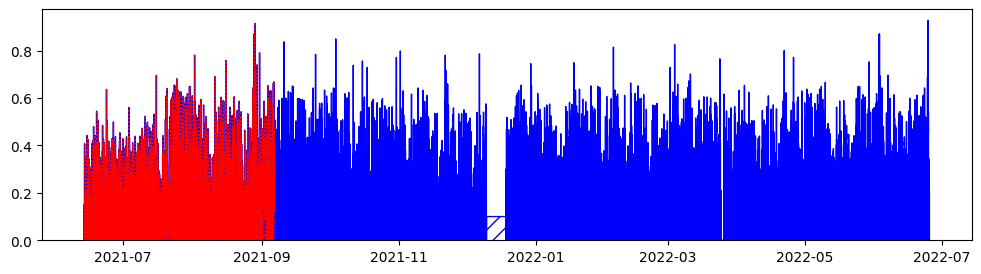

In [16]:
random_patient= np.random.choice(np.intersect1d(df_basal_new.PtID.unique(),df_basal_old.PtID.unique()),1)[0]
print(f"Random patient: {random_patient}")

df_basal_new_patient = df_basal_new[df_basal_new.PtID == random_patient]
df_basal_old_patient = df_basal_old[df_basal_old.PtID == random_patient]

plt.figure(figsize=(12, 3));ax=plt.gca()
#plt.scatter(df_basal_new_patient.date.unique(), [0]*len(df_basal_new_patient.date.unique()), label='New Release', color='blue')
#plt.scatter(df_basal_old_patient.date.unique(), [1]*len(df_basal_old_patient.date.unique()), label='Old Release', color='orange')
#plt.ylim(-0.5, 1.5)
drawing.drawAbsoluteBasalRates(ax,df_basal_new_patient.datetime.values, df_basal_new_patient.BasalRate.values,edgecolor='blue')
drawing.drawAbsoluteBasalRates(ax,df_basal_old_patient.datetime.values, df_basal_old_patient.BasalRate.values,edgecolor='red',alpha=1,linestyle=':')
#plt.xlim(start-timedelta(hours=12), start+timedelta(hours=36))


In [17]:
results = []

for patient_id in np.intersect1d(df_basal_new.PtID.unique(), df_basal_old.PtID.unique()):
    df_basal_new_patient = df_basal_new[df_basal_new.PtID == patient_id]
    df_basal_old_patient = df_basal_old[df_basal_old.PtID == patient_id]

    df_basal_new_patient_inters = df_basal_new_patient.loc[df_basal_new_patient.datetime.between(df_basal_old_patient.datetime.min(),
                                                                                                 df_basal_old_patient.datetime.max(),
                                                                                                 inclusive='both')]

    temp = pd.merge(
        df_basal_old_patient[['datetime', 'BasalRate']],
        df_basal_new_patient_inters[['datetime', 'BasalRate']],
        on='datetime',
        how='outer',
        suffixes=('_old', '_new')
    ).sort_values(by='datetime')

    diff_stats = (temp.BasalRate_new - temp.BasalRate_old).describe()
    results.append({
        'PtID': patient_id,
        'old_length': len(df_basal_old_patient),
        'new_length_intersection': len(df_basal_new_patient_inters),
        'length_diff': len(df_basal_new_patient_inters) - len(df_basal_old_patient),
        'mean_diff': diff_stats['mean'],
        'std_diff': diff_stats['std'],
        'min_diff': diff_stats['min'],
        'max_diff': diff_stats['max']
    })

results_df = pd.DataFrame(results)
display(results_df)

results_df.mean_diff.describe()


,PtID,old_length,new_length_intersection,length_diff,mean_diff,std_diff,min_diff,max_diff
0,3,7850,23124,15274,-6.767880e-10,8.279298e-09,-5.531311e-08,3.051758e-08
1,4,5024,28326,23302,-6.417405e-10,5.010324e-09,-2.956390e-08,2.956390e-08
2,5,9399,26028,16629,-7.220886e-10,7.351061e-09,-2.956390e-08,2.908707e-08
3,8,25497,27963,2466,3.486401e-10,6.128071e-09,-4.386902e-08,5.912781e-08
4,9,9688,27649,17961,1.183882e-10,1.076440e-08,-5.817413e-08,5.817413e-08
...,...,...,...,...,...,...,...,...
60,102,6392,26458,20066,-1.049153e-09,5.186310e-09,-2.765655e-08,2.956390e-08
61,103,11465,27853,16388,-2.211211e-10,9.702652e-09,-5.912781e-08,5.626678e-08
62,106,23179,26653,3474,5.682170e-10,8.354518e-09,-5.912781e-08,5.912781e-08
63,107,7851,23932,16081,-1.546182e-09,9.751617e-09,-5.340576e-08,5.245209e-08


count    6.500000e+01
mean     7.563825e-07
std      5.615544e-06
min     -5.661281e-08
25%     -9.682473e-10
50%     -5.139772e-10
75%     -2.371724e-10
max      4.515223e-05
Name: mean_diff, dtype: float64

We see that for patient 3 for example the number of events of the intersection is much larger. Still on visual inspection everything looks okay. Whats going on?

The number of basal rates for patient 9 in the old release is 9688 and in the intersection of new release is 27649.


,PtID,RecID,DeviceDtTm,BasalRate,datetime,date,TrtGroup
47790,9,47837,10/25/2020 2:28:42 PM,0.200,2020-10-25 14:28:42,2020-10-25,CLC
47791,9,47838,10/25/2020 4:03:55 PM,0.190,2020-10-25 16:03:55,2020-10-25,CLC
47792,9,47839,10/25/2020 5:04:04 PM,0.200,2020-10-25 17:04:04,2020-10-25,CLC
47793,9,47840,10/25/2020 6:04:13 PM,0.170,2020-10-25 18:04:13,2020-10-25,CLC
47794,9,47841,10/25/2020 6:29:16 PM,0.000,2020-10-25 18:29:16,2020-10-25,CLC
47795,9,47842,10/25/2020 7:04:09 PM,0.170,2020-10-25 19:04:09,2020-10-25,CLC
47796,9,47843,10/25/2020 7:34:14 PM,0.272,2020-10-25 19:34:14,2020-10-25,CLC
47797,9,47844,10/25/2020 7:39:15 PM,0.257,2020-10-25 19:39:15,2020-10-25,CLC


,RecID,PtID,DeviceDtTm,BasalRate,datetime,date,TrtGroup
1752623,2232476,9,10/25/2020 2:28:42 PM,0.2,2020-10-25 14:28:42,2020-10-25,CLC
1752624,2232477,9,10/25/2020 2:33:42 PM,0.2,2020-10-25 14:33:42,2020-10-25,CLC
1752625,2232478,9,10/25/2020 2:38:42 PM,0.2,2020-10-25 14:38:42,2020-10-25,CLC
1752626,2232479,9,10/25/2020 2:43:43 PM,0.2,2020-10-25 14:43:43,2020-10-25,CLC
1752627,2232480,9,10/25/2020 2:48:44 PM,0.2,2020-10-25 14:48:44,2020-10-25,CLC
1752628,2232481,9,10/25/2020 2:53:45 PM,0.2,2020-10-25 14:53:45,2020-10-25,CLC
1752629,2232482,9,10/25/2020 2:58:45 PM,0.2,2020-10-25 14:58:45,2020-10-25,CLC
1752630,2232483,9,10/25/2020 3:03:46 PM,0.2,2020-10-25 15:03:46,2020-10-25,CLC


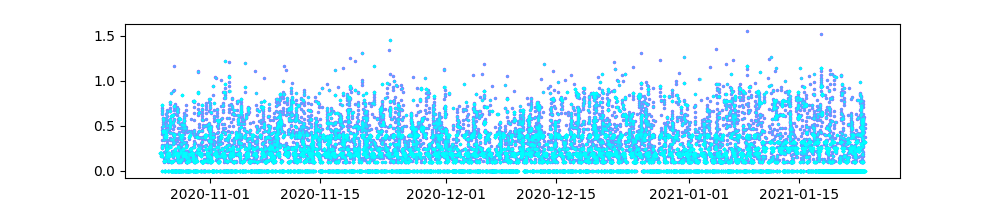

In [41]:
random_patient= 9

df_basal_new_patient = df_basal_new[df_basal_new.PtID == random_patient]
df_basal_old_patient = df_basal_old[df_basal_old.PtID == random_patient]
df_basal_new_patient_inters = df_basal_new_patient.loc[df_basal_new_patient.datetime.between(df_basal_old_patient.datetime.min(),
                                                                                                 df_basal_old_patient.datetime.max(),
                                                                                                 inclusive='both')]

print(f"The number of basal rates for patient {random_patient} in the old release is {len(df_basal_old_patient)} and in the intersection of new release is {len(df_basal_new_patient_inters)}.")


plt.figure(figsize=(10, 2));ax=plt.gca()    
ax.scatter(df_basal_old_patient.datetime.values, df_basal_old_patient.BasalRate.values,color='magenta',s=2)
ax.scatter(df_basal_new_patient_inters.datetime.values, df_basal_new_patient_inters.BasalRate.values,color='cyan',alpha=0.5,s=2)

display(df_basal_old_patient.sort_values('datetime').head(8))
display(df_basal_new_patient_inters.sort_values('datetime').head(8))

It looks like the same basal rates are reported several times. 

After dropping repetitive values, the number of basal rates for patient 9 in the old release is 9632 and in the intersection of new release is 11517.


,PtID,RecID,DeviceDtTm,BasalRate,datetime,date,TrtGroup
47790,9,47837,10/25/2020 2:28:42 PM,0.200,2020-10-25 14:28:42,2020-10-25,CLC
47791,9,47838,10/25/2020 4:03:55 PM,0.190,2020-10-25 16:03:55,2020-10-25,CLC
47792,9,47839,10/25/2020 5:04:04 PM,0.200,2020-10-25 17:04:04,2020-10-25,CLC
47793,9,47840,10/25/2020 6:04:13 PM,0.170,2020-10-25 18:04:13,2020-10-25,CLC
47794,9,47841,10/25/2020 6:29:16 PM,0.000,2020-10-25 18:29:16,2020-10-25,CLC
47795,9,47842,10/25/2020 7:04:09 PM,0.170,2020-10-25 19:04:09,2020-10-25,CLC
47796,9,47843,10/25/2020 7:34:14 PM,0.272,2020-10-25 19:34:14,2020-10-25,CLC
47797,9,47844,10/25/2020 7:39:15 PM,0.257,2020-10-25 19:39:15,2020-10-25,CLC
47798,9,47845,10/25/2020 7:44:16 PM,0.260,2020-10-25 19:44:16,2020-10-25,CLC
47799,9,47846,10/25/2020 7:49:16 PM,0.293,2020-10-25 19:49:16,2020-10-25,CLC


,RecID,PtID,DeviceDtTm,BasalRate,datetime,date,TrtGroup
1752623,2232476,9,10/25/2020 2:28:42 PM,0.200,2020-10-25 14:28:42,2020-10-25,CLC
1752642,2232495,9,10/25/2020 4:03:55 PM,0.190,2020-10-25 16:03:55,2020-10-25,CLC
1752654,2232507,9,10/25/2020 5:04:04 PM,0.200,2020-10-25 17:04:04,2020-10-25,CLC
1752666,2232519,9,10/25/2020 6:04:13 PM,0.170,2020-10-25 18:04:13,2020-10-25,CLC
1752671,2232524,9,10/25/2020 6:29:16 PM,0.000,2020-10-25 18:29:16,2020-10-25,CLC
1753074,2232964,9,10/25/2020 7:04:09 PM,0.170,2020-10-25 19:04:09,2020-10-25,CLC
1753080,2232970,9,10/25/2020 7:34:14 PM,0.272,2020-10-25 19:34:14,2020-10-25,CLC
1753081,2232971,9,10/25/2020 7:39:15 PM,0.257,2020-10-25 19:39:15,2020-10-25,CLC
1753082,2232972,9,10/25/2020 7:44:16 PM,0.260,2020-10-25 19:44:16,2020-10-25,CLC
1753083,2232973,9,10/25/2020 7:49:16 PM,0.293,2020-10-25 19:49:16,2020-10-25,CLC


/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_80089/688892806.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = plt.figure(figsize=(10, 2));ax=plt.gca()
/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_80089/688892806.py:30: UserWarning: You passed a edgecolor/edgecolors ('None') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_basal_new_patient_inters_drop_repetitive.datetime.values,


Text(0.5, 1.0, 'Basal Rate Comparison for Patient 9')

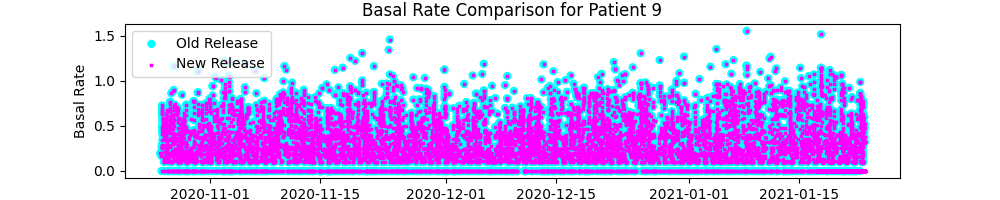

In [64]:
def drop_repetitive_values(df, column):
    """
    Drops rows with repetitive values in the specified column, keeping only rows where the value changes.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        column (str): The column to check for repetitive values.

    Returns:
        pd.DataFrame: A DataFrame with repetitive values dropped.
    """
    df = df.sort_values('datetime')  # Ensure the DataFrame is sorted by datetime
    df['diff'] = df[column].diff()  # Calculate the difference between consecutive rows
    result = df.loc[df['diff'] != 0].drop(columns=['diff'])  # Keep rows where the value changes
    return result
%matplotlib widget
#drop repetitives
df_basal_new_patient_inters_drop_repetitive = drop_repetitive_values(df_basal_new_patient_inters, 'BasalRate').sort_values('datetime')
df_basal_old_patient_drop_repetitive = drop_repetitive_values(df_basal_old_patient, 'BasalRate').sort_values('datetime')

print(f"After dropping repetitive values, the number of basal rates for patient {random_patient} in the old release is {len(df_basal_old_patient_drop_repetitive)} and in the intersection of new release is {len(df_basal_new_patient_inters_drop_repetitive)}.")
#compare
display(df_basal_old_patient_drop_repetitive.sort_values('datetime').head(10))
display(df_basal_new_patient_inters_drop_repetitive.sort_values('datetime').head(10))


f = plt.figure(figsize=(10, 2));ax=plt.gca()    
ax.scatter(df_basal_old_patient_drop_repetitive.datetime.values, 
           df_basal_old_patient_drop_repetitive.BasalRate.values,color='cyan',edgecolors='None',label='Old Release')
ax.scatter(df_basal_new_patient_inters_drop_repetitive.datetime.values,
            df_basal_new_patient_inters_drop_repetitive.BasalRate.values,color='magenta',alpha=1,edgecolors='None',label='New Release',marker='x',s=4)
plt.legend()
plt.xlabel('Datetime')
plt.ylabel('Basal Rate')
plt.title('Basal Rate Comparison for Patient {}'.format(random_patient))

At first glance all look alike then we see alternations between 0.325 and 0 which are not present in the old dataset.

2020-10-25 14:28:42 2021-01-23 10:15:50


,RecID,PtID,DeviceDtTm,BasalRate,datetime,date,TrtGroup
1645683,2124343,9,1/23/2021 6:03:47 AM,0.636,2021-01-23 06:03:47,2021-01-23,CLC
5208510,5932816,9,1/23/2021 6:04:42 AM,0.000,2021-01-23 06:04:42,2021-01-23,CLC
1645684,2124344,9,1/23/2021 6:08:48 AM,0.713,2021-01-23 06:08:48,2021-01-23,CLC
5208511,5932817,9,1/23/2021 6:09:43 AM,0.000,2021-01-23 06:09:43,2021-01-23,CLC
1645685,2124345,9,1/23/2021 6:13:49 AM,0.747,2021-01-23 06:13:49,2021-01-23,CLC
5208512,5932818,9,1/23/2021 6:14:42 AM,0.000,2021-01-23 06:14:42,2021-01-23,CLC
1645686,2124346,9,1/23/2021 6:18:51 AM,0.772,2021-01-23 06:18:51,2021-01-23,CLC
5208513,5932819,9,1/23/2021 6:19:43 AM,0.000,2021-01-23 06:19:43,2021-01-23,CLC
1645687,2124347,9,1/23/2021 6:23:51 AM,0.325,2021-01-23 06:23:51,2021-01-23,CLC
5208514,5932820,9,1/23/2021 6:24:42 AM,0.000,2021-01-23 06:24:42,2021-01-23,CLC


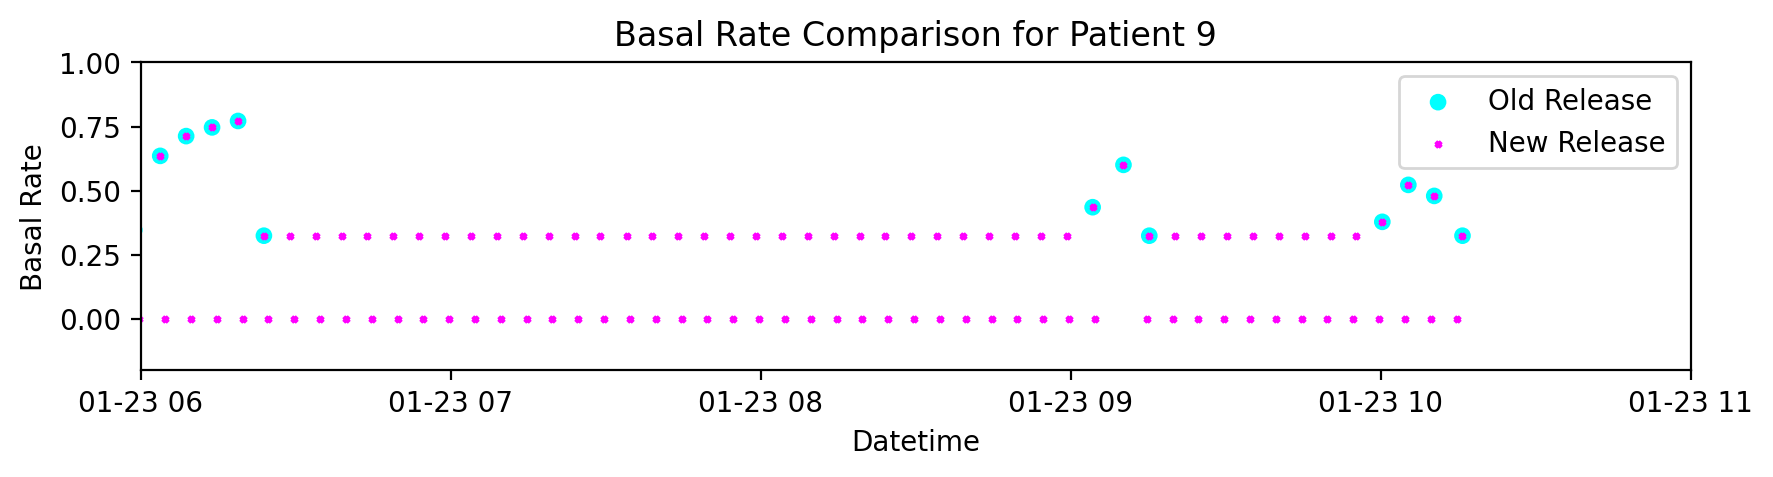

In [63]:
print(df_basal_new_patient_inters_drop_repetitive.datetime.min(),df_basal_new_patient_inters_drop_repetitive.datetime.max())
start = datetime(2021,1,23,6)
end = datetime(2021,1,23,11)
display(df_basal_new_patient_inters_drop_repetitive.loc[df_basal_new_patient_inters_drop_repetitive.datetime.between(start, end)].head(10))

ax.set_xlim((start,end))
ax.set_ylim((-.2, 1))
f
#plt.savefig('basal_rate_comparison.png', dpi=300, bbox_inches='tight')



We see that these counts are much closer, however some still differ quite a bit.

Also, we noticed that when trying to match the tables exactly, this does not work because of rounding differences:

In [21]:
temp_new = df_basal_new_patient_inters_drop_repetitive[['datetime','BasalRate']].sort_values('datetime').copy()
temp_old = df_basal_old_patient_drop_repetitive[['datetime','BasalRate']].sort_values('datetime').copy()
merged = temp_new.merge(temp_old,on=['datetime','BasalRate'], how='outer',indicator=True)
display(merged.head(8))

print(merged.iloc[0].BasalRate)
print(merged.iloc[1].BasalRate)

merged['_merge'].value_counts()

,datetime,BasalRate,_merge
0,2020-10-25 14:28:42,0.20,left_only
1,2020-10-25 14:28:42,0.20,right_only
2,2020-10-25 16:03:55,0.19,right_only
3,2020-10-25 16:03:55,0.19,left_only
4,2020-10-25 17:04:04,0.20,left_only
5,2020-10-25 17:04:04,0.20,right_only
6,2020-10-25 18:04:13,0.17,left_only
7,2020-10-25 18:04:13,0.17,right_only


0.2
0.200000002980232


_merge
left_only     10634
right_only     8749
both            883
Name: count, dtype: int64

They look the same but they arent. They need to be rounded.

In [22]:
temp_old['BasalRate'] = temp_old['BasalRate'].round(3)
temp_new['BasalRate'] = temp_new['BasalRate'].round(3)
merged = temp_new.merge(temp_old,on=['datetime','BasalRate'], how='outer',indicator=True)
display(merged.head(4))

print(temp_old.iloc[0].BasalRate)
print(temp_new.iloc[0].BasalRate)

merged['_merge'].value_counts()

,datetime,BasalRate,_merge
0,2020-10-25 14:28:42,0.20,both
1,2020-10-25 16:03:55,0.19,both
2,2020-10-25 17:04:04,0.20,both
3,2020-10-25 18:04:13,0.17,both


0.2
0.2


_merge
both          9556
left_only     1961
right_only      76
Name: count, dtype: int64

Rerun analysis

In [23]:
results = []

for patient_id in np.intersect1d(df_basal_new.PtID.unique(), df_basal_old.PtID.unique()):
    df_basal_new_patient = drop_repetitive_values(df_basal_new[df_basal_new.PtID == patient_id], 'BasalRate')
    df_basal_old_patient = drop_repetitive_values(df_basal_old[df_basal_old.PtID == patient_id], 'BasalRate')

    df_basal_new_patient_inters = df_basal_new_patient.loc[df_basal_new_patient.datetime.between(df_basal_old_patient.datetime.min(),
                                                                                                 df_basal_old_patient.datetime.max(),
                                                                                                 inclusive='both')]

    temp = pd.merge(
        df_basal_old_patient[['datetime', 'BasalRate']],
        df_basal_new_patient_inters[['datetime', 'BasalRate']],
        on='datetime',
        how='outer',
        suffixes=('_old', '_new')
    ).sort_values(by='datetime')

    diff_stats = (temp.BasalRate_new - temp.BasalRate_old).describe()
    results.append({
        'PtID': patient_id,
        'old_length': len(df_basal_old_patient),
        'new_length_inters': len(df_basal_new_patient_inters),
        'length_diff': len(df_basal_new_patient_inters) - len(df_basal_old_patient),
        'mean_diff': diff_stats['mean'],
        'std_diff': diff_stats['std'],
        'min_diff': diff_stats['min'],
        'max_diff': diff_stats['max']
    })

results_df = pd.DataFrame(results)
display(results_df)

,PtID,old_length,new_length_inters,length_diff,mean_diff,std_diff,min_diff,max_diff
0,3,7643,7635,-8,-6.600133e-10,8.378883e-09,-5.531311e-08,3.051758e-08
1,4,4758,4939,181,-6.047898e-10,5.139192e-09,-2.956390e-08,2.956390e-08
2,5,9323,9320,-3,-7.168659e-10,7.378013e-09,-2.956390e-08,2.908707e-08
3,8,9986,9985,-1,8.230952e-11,8.895916e-09,-4.386902e-08,5.912781e-08
4,9,9632,11517,1885,1.267753e-10,1.081888e-08,-5.817413e-08,5.817413e-08
...,...,...,...,...,...,...,...,...
60,102,6214,6205,-9,-1.036430e-09,5.254701e-09,-2.765655e-08,2.956390e-08
61,103,11416,11411,-5,-2.188273e-10,9.714104e-09,-5.912781e-08,5.626678e-08
62,106,11075,11064,-11,2.450859e-10,1.015161e-08,-5.912781e-08,5.912781e-08
63,107,7801,7794,-7,-1.546222e-09,9.779669e-09,-5.340576e-08,5.245209e-08


<Axes: >

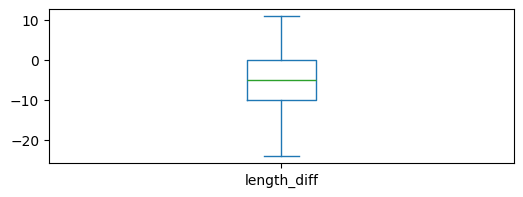

In [24]:
plt.figure(figsize=(6,2))
results_df.length_diff.plot.box(showfliers=False)
#plt.ylim(0,15000)

However, in average we see that the new dataset has more events. So patient 9 was an exception with more events.

In summary

 - The new dataset 
  - uses a different filename
  - contains much more basal data
    - 245 vs. 89 days per patient (average)
    - SC patients used Tandem after week 13, this data was added
      - Increasing number of patients to 99 (prior 65)
 - The intersecting regions of the new and old dataset look almost identical but
  - the number of events slightly differs (in average 10 events less, sometimes thousands more)
	- For instance for patient 9, the end region has frequent alternating values while the old dataset didn’t (unclear why).
  - the old dataset seems to be rounded, the old one had tailing decimal places (negligible)